In [90]:
import os
import cv2
import json
import joblib
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
 
import sklearn, sys
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity
from skimage.feature import hog
 
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode
 
from roi_mediapipe import detect_palm_opencv
 
warnings.filterwarnings('ignore')
 
print(f"sklearn : {sklearn.__version__}")
print(f"python  : {sys.executable}")

sklearn : 1.7.2
python  : c:\python313\python.exe


### BAGIAN 1 — KONFIGURASI

In [91]:
class Config:
    DATASET_PATH = r'D:\xampp\htdocs\palmprint-backend\palmprint-ml\dataset'
    OUTPUT_PATH  = 'results'
    MODELS_DIR   = 'models'
 
    # ROI
    ROI_SIZE   = 200
    IMAGE_SIZE = 64          # resize sebelum HOG (paper: 64×64)
 
    # HOG
    HOG_ORIENT = 9
    HOG_PIXELS = 8          # pixels per cell
    HOG_CELLS  = 2           # cells per block
 
    # SGF — 24 orientasi, step 15°
    SGF_ANGLES = np.deg2rad(np.arange(0, 360, 15))
 
    # CLAHE
    CLAHE_CLIP = 2.0
    CLAHE_TILE = (8, 8)
 
    # Gabor
    GABOR_KSIZE  = 31
    GABOR_SIGMA  = 4.0
    GABOR_LAMBDA = 20.0
    GABOR_GAMMA  = 0.5
    GABOR_THETAS = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    
 
    # PCA — jumlah komponen dipilih otomatis berdasarkan variance
    PCA_VARIANCE = 0.99
 
for d in [Config.OUTPUT_PATH, Config.MODELS_DIR]:
    os.makedirs(d, exist_ok=True)
 
print('✓ Konfigurasi siap')
print(f'  Dataset  : {Config.DATASET_PATH}')
print(f'  PCA      : {int(Config.PCA_VARIANCE * 100)}% variance otomatis')
print(f'  HOG      : orient={Config.HOG_ORIENT}, cell={Config.HOG_PIXELS}px, block={Config.HOG_CELLS}cells')

✓ Konfigurasi siap
  Dataset  : D:\xampp\htdocs\palmprint-backend\palmprint-ml\dataset
  PCA      : 99% variance otomatis
  HOG      : orient=9, cell=8px, block=2cells


### BAGIAN 2 — PREPROCESSING: NORMALISASI PENCAHAYAAN + GABOR ENHANCEMENT

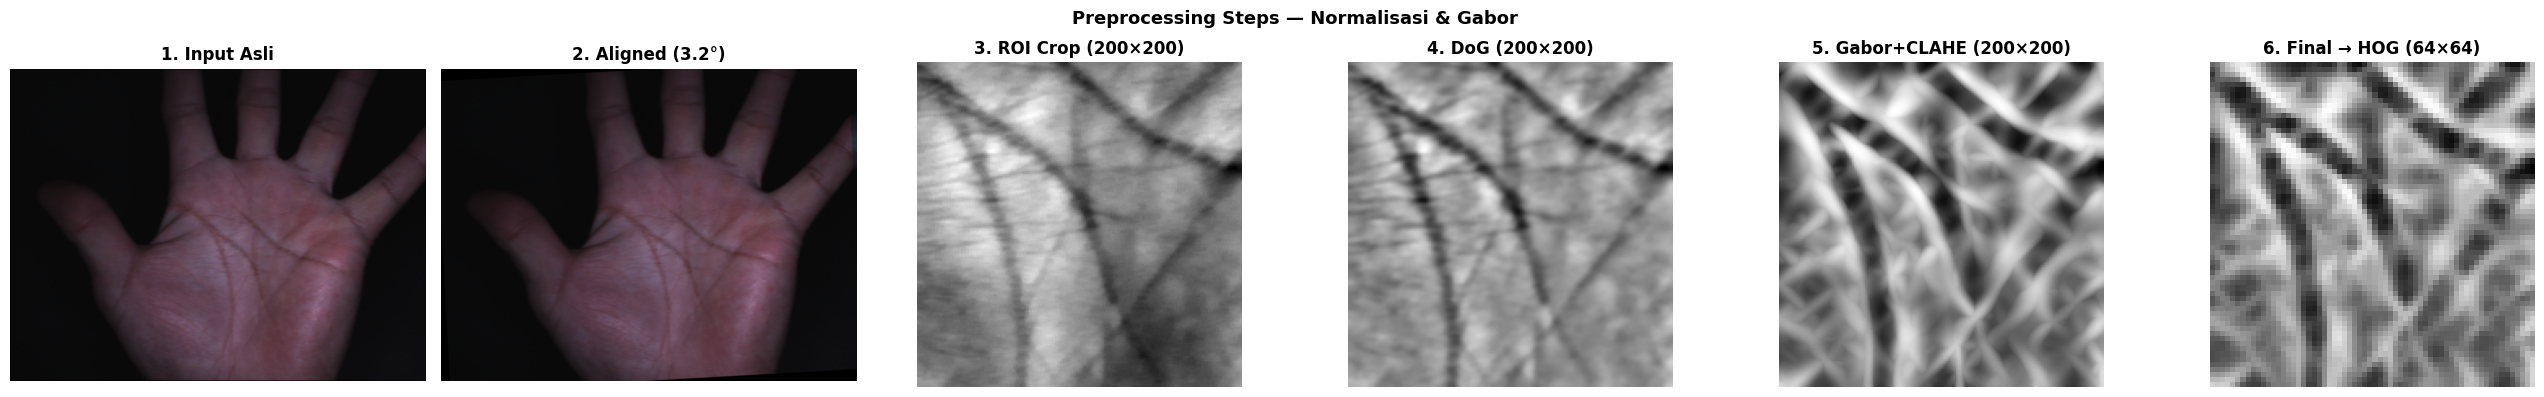

✓ Visualisasi preprocessing selesai
  ROI shape     : (200, 200)
  Angle         : 3.21°
  Fallback      : False
  Dynamic size  : 200 px
  HOG input size: (64, 64)


In [92]:
def normalize_illumination(img_gray):
    """
    Normalisasi pencahayaan dengan Difference of Gaussians (DoG).
 
    Masalah: Foto dari HP punya variasi brightness (terang/gelap/bayangan).
    Solusi : DoG memisahkan tekstur dari pencahayaan global.
 
    Cara kerja:
        DoG = Gaussian(σ=1) - Gaussian(σ=10)
        σ=1  → tangkap detail halus (~3px)
        σ=10 → tangkap cahaya global (~30px)
        Selisihnya = tekstur murni, bebas pencahayaan global
 
    Kenapa bukan CLAHE saja:
        CLAHE meningkatkan kontras lokal tapi tidak menghilangkan variasi
        pencahayaan global. DoG benar-benar memisahkan keduanya.
    """
    img_f   = img_gray.astype(np.float32)
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=1.0)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=10.0)
    dog     = g_small - g_large
    return cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
 
 
def enhance_gabor(img_gray, ksize=None, sigma=None, lambd=None,
                  gamma=None, thetas=None, use_dog=False):
    """
    Gabor filter bank multi-orientasi + CLAHE.
 
    Args:
        use_dog : jika True, jalankan normalize_illumination sebelum Gabor
    """
    ksize  = ksize  or Config.GABOR_KSIZE
    sigma  = sigma  or Config.GABOR_SIGMA
    lambd  = lambd  or Config.GABOR_LAMBDA
    gamma  = gamma  or Config.GABOR_GAMMA
    thetas = thetas or Config.GABOR_THETAS
 
    if use_dog:
        img_gray = normalize_illumination(img_gray)
 
    responses = []
    for theta in thetas:
        kernel = cv2.getGaborKernel(
            ksize=(ksize, ksize), sigma=sigma, theta=theta,
            lambd=lambd, gamma=gamma, psi=0, ktype=cv2.CV_32F
        )
        resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
        responses.append(np.abs(resp))
 
    gabor_max = np.max(responses, axis=0)
    gabor_max = cv2.normalize(gabor_max, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe     = cv2.createCLAHE(clipLimit=Config.CLAHE_CLIP, tileGridSize=Config.CLAHE_TILE)
    return clahe.apply(gabor_max)
 
# ── Visualisasi preprocessing pada 1 sample ──
exts    = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
samples = [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]

if samples:
    img_s = cv2.imread(os.path.join(Config.DATASET_PATH, samples[0]))

    # Step 1: ROI crop → grayscale 200×200
    roi_gray, dbg = detect_palm_opencv(img_s)

    # ✅ PERBAIKAN: DoG dan Gabor pada ROI 200×200, BUKAN 64×64
    dog_s       = normalize_illumination(roi_gray)        # DoG pada 200×200
    gabor_s     = enhance_gabor(roi_gray, use_dog=False)  # Gabor pada 200×200
    gabor_dog_s = enhance_gabor(roi_gray, use_dog=True)   # Gabor+DoG pada 200×200

    # Resize ke 64×64 HANYA untuk keperluan HOG downstream (jangan dipakai visualisasi)
    roi_for_hog = cv2.resize(gabor_dog_s, (Config.IMAGE_SIZE, Config.IMAGE_SIZE),
                             interpolation=cv2.INTER_AREA)  # INTER_AREA untuk downscale

    fig, axes = plt.subplots(1, 6, figsize=(26, 4))
    fig.suptitle('Preprocessing Steps — Normalisasi & Gabor', fontsize=13, fontweight='bold')

    axes[0].imshow(cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB))
    axes[0].set_title('1. Input Asli', fontweight='bold'); axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(dbg['img_aligned'], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'2. Aligned ({dbg["angle"]:.1f}°)', fontweight='bold'); axes[1].axis('off')

    axes[2].imshow(roi_gray, cmap='gray')
    axes[2].set_title('3. ROI Crop (200×200)', fontweight='bold'); axes[2].axis('off')

    axes[3].imshow(dog_s, cmap='gray')
    axes[3].set_title('4. DoG (200×200)', fontweight='bold'); axes[3].axis('off')

    axes[4].imshow(gabor_dog_s, cmap='gray')
    axes[4].set_title('5. Gabor+CLAHE (200×200)', fontweight='bold'); axes[4].axis('off')

    axes[5].imshow(roi_for_hog, cmap='gray')
    axes[5].set_title('6. Final → HOG (64×64)', fontweight='bold'); axes[5].axis('off')

    plt.tight_layout()
    plt.show()
    print('✓ Visualisasi preprocessing selesai')
    print(f'  ROI shape     : {roi_gray.shape}')
    print(f'  Angle         : {dbg["angle"]:.2f}°')
    print(f'  Fallback      : {dbg["fallback"]}')
    print(f'  Dynamic size  : {dbg["dynamic_roi_size"]} px')
    print(f'  HOG input size: {roi_for_hog.shape}')

In [93]:
# test_params2 = [
#     {'ksize': 31, 'lambda': 20, 'label': 'ksize=31, λ=20 (winner)'},
#     {'ksize': 31, 'lambda': 25, 'label': 'ksize=31, λ=25'},
#     {'ksize': 35, 'lambda': 20, 'label': 'ksize=35, λ=20'},
#     {'ksize': 35, 'lambda': 25, 'label': 'ksize=35, λ=25'},
# ]

# fig, axes = plt.subplots(1, len(test_params2)+1, figsize=(24, 4))
# fig.suptitle('Gabor Parameter Tuning Round 2', fontsize=13, fontweight='bold')

# axes[0].imshow(roi_gray, cmap='gray')
# axes[0].set_title('ROI Original', fontweight='bold'); axes[0].axis('off')

# for i, p in enumerate(test_params2):
#     result = enhance_gabor(
#         roi_gray,
#         ksize=p['ksize'],
#         sigma=4.0,
#         lambd=p['lambda'],
#         gamma=0.5,
#         thetas=Config.GABOR_THETAS,
#         use_dog=True
#     )
#     axes[i+1].imshow(result, cmap='gray')
#     axes[i+1].set_title(p['label'], fontweight='bold')
#     axes[i+1].axis('off')

# plt.tight_layout()
# plt.show()

### BAGIAN 3 — AUGMENTASI ROI (TRAINING ONLY)

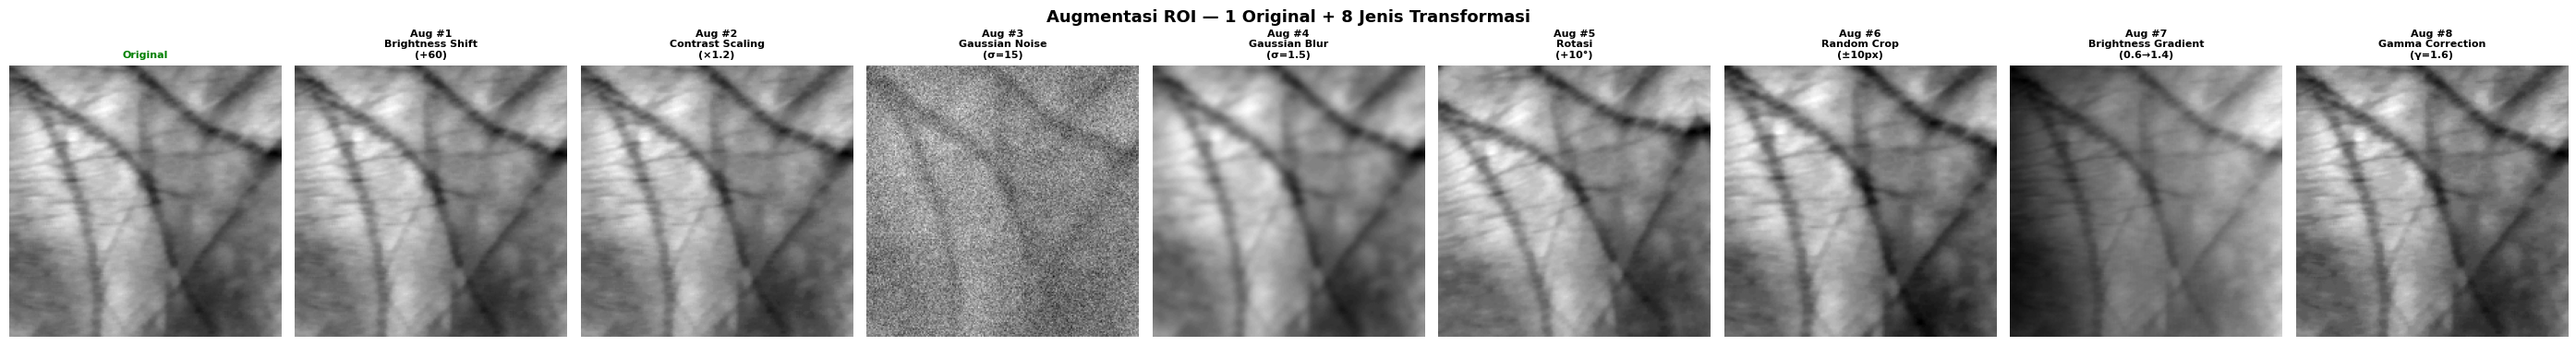

✓ Visualisasi augmentasi untuk laporan selesai
  Tersimpan: results/augmentasi_laporan.png


In [94]:
def augment_roi(roi_gray, n_aug=3):
    """
    Augmentasi ROI palmprint untuk memperbanyak data training.

    Augmentasi yang DIPILIH (aman untuk palmprint):
      1. Brightness shift ±60     → simulasi variasi cahaya HP (diperlebar dari ±30)
      2. Contrast scaling 0.8–1.2 → simulasi variasi exposure
      3. Gaussian noise σ=5–15    → simulasi noise sensor kamera
      4. Gaussian blur σ=0.5–1.5  → simulasi slight defocus
      5. Rotasi kecil ±10°        → toleransi sisa error alignment
      6. Random crop ±15px        → toleransi pergeseran centroid
      7. Brightness gradient      → simulasi bayangan/cahaya tidak merata dari HP
      8. Gamma correction         → simulasi auto-exposure HP yang berbeda-beda

    Augmentasi yang DIHINDARI:
      - Flip horizontal/vertikal  → garis tangan kiri ≠ kanan
      - Rotasi besar (>20°)       → sudah ditangani alignment
      - Elastic distortion        → merusak struktur garis palmprint

    Args:
        roi_gray : grayscale ROI (np.uint8), ukuran ROI_SIZE × ROI_SIZE
        n_aug    : jumlah augmentasi per gambar (total dataset = n_aug+1 x)

    Returns:
        list of np.uint8 : ROI hasil augmentasi (tidak termasuk original)
    """
    h, w = roi_gray.shape[:2]
    results = []

    for _ in range(n_aug):
        aug = roi_gray.copy().astype(np.float32)

        # 1. Brightness shift ±60 (diperlebar dari ±30 untuk simulasi HP)
        if np.random.random() < 0.5:
            aug = np.clip(aug + np.random.uniform(-60, 60), 0, 255)

        # 2. Contrast scaling
        if np.random.random() < 0.4:
            aug = np.clip(aug * np.random.uniform(0.8, 1.2), 0, 255)

        # 3. Gaussian noise
        if np.random.random() < 0.5:
            noise = np.random.normal(0, np.random.uniform(5, 15), aug.shape)
            aug = np.clip(aug + noise, 0, 255)

        # 4. Gaussian blur ringan
        if np.random.random() < 0.4:
            aug = cv2.GaussianBlur(aug, (0, 0), np.random.uniform(0.5, 1.5))

        # 5. Rotasi kecil ±10°
        if np.random.random() < 0.6:
            angle = np.random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            aug = cv2.warpAffine(
                aug, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT
            )

        # 6. Random crop + resize balik
        if np.random.random() < 0.5:
            margin = 15
            x1 = np.random.randint(0, margin)
            y1 = np.random.randint(0, margin)
            x2 = w - np.random.randint(0, margin)
            y2 = h - np.random.randint(0, margin)
            aug = cv2.resize(aug[y1:y2, x1:x2], (w, h), interpolation=cv2.INTER_LINEAR)

        # 7. Brightness gradient (simulasi bayangan/cahaya tidak merata dari HP)
        if np.random.random() < 0.5:
            gradient = np.linspace(
                np.random.uniform(0.6, 1.0),
                np.random.uniform(1.0, 1.4),
                w
            ).astype(np.float32)
            aug = np.clip(aug * gradient[np.newaxis, :], 0, 255)

        # 8. Gamma correction (simulasi auto-exposure HP yang berbeda-beda)
        if np.random.random() < 0.5:
            gamma = np.random.uniform(0.6, 1.6)
            aug_norm = aug / 255.0
            aug_norm = np.clip(aug_norm, 1e-7, 1.0)  # hindari log(0)
            aug = np.clip(255.0 * (aug_norm ** gamma), 0, 255)

        results.append(aug.astype(np.uint8))

    return results

# ── Visualisasi augmentasi DETERMINISTIK untuk laporan ──
if samples:
    roi_s, _ = detect_palm_opencv(img_s)
    h, w = roi_s.shape[:2]

    def apply_single(roi, aug_type):
        aug = roi.copy().astype(np.float32)
        if aug_type == 1:  # Brightness shift
            aug = np.clip(aug + 60, 0, 255)
        elif aug_type == 2:  # Contrast scaling
            aug = np.clip(aug * 1.2, 0, 255)
        elif aug_type == 3:  # Gaussian noise
            noise = np.random.normal(0, 15, aug.shape)
            aug = np.clip(aug + noise, 0, 255)
        elif aug_type == 4:  # Gaussian blur
            aug = cv2.GaussianBlur(aug, (0, 0), 1.5)
        elif aug_type == 5:  # Rotasi
            M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1.0)
            aug = cv2.warpAffine(aug, M, (w, h), flags=cv2.INTER_LINEAR,
                                 borderMode=cv2.BORDER_REFLECT)
        elif aug_type == 6:  # Random crop
            x1, y1, x2, y2 = 10, 10, w-10, h-10
            aug = cv2.resize(aug[y1:y2, x1:x2], (w, h), interpolation=cv2.INTER_LINEAR)
        elif aug_type == 7:  # Brightness gradient
            gradient = np.linspace(0.6, 1.4, w).astype(np.float32)
            aug = np.clip(aug * gradient[np.newaxis, :], 0, 255)
        elif aug_type == 8:  # Gamma correction
            aug_norm = np.clip(aug / 255.0, 1e-7, 1.0)
            aug = np.clip(255.0 * (aug_norm ** 1.6), 0, 255)
        return aug.astype(np.uint8)

    labels = [
        'Original',
        'Aug #1\nBrightness Shift\n(+60)',
        'Aug #2\nContrast Scaling\n(×1.2)',
        'Aug #3\nGaussian Noise\n(σ=15)',
        'Aug #4\nGaussian Blur\n(σ=1.5)',
        'Aug #5\nRotasi\n(+10°)',
        'Aug #6\nRandom Crop\n(±10px)',
        'Aug #7\nBrightness Gradient\n(0.6→1.4)',
        'Aug #8\nGamma Correction\n(γ=1.6)',
    ]

    aug_images = [roi_s] + [apply_single(roi_s, i) for i in range(1, 9)]

    fig, axes = plt.subplots(1, 9, figsize=(28, 4))
    fig.suptitle(
        "Augmentasi ROI — 1 Original + 8 Jenis Transformasi",
        fontsize=13, fontweight="bold"
    )

    for i, (img_aug, label) in enumerate(zip(aug_images, labels)):
        axes[i].imshow(img_aug, cmap='gray')
        color = 'green' if i == 0 else 'black'
        axes[i].set_title(label, fontweight='bold', color=color, fontsize=8)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('results/augmentasi_laporan.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Visualisasi augmentasi untuk laporan selesai")
    print("  Tersimpan: results/augmentasi_laporan.png")

### BAGIAN 4 — EKSTRAKSI FITUR HOG-SGF

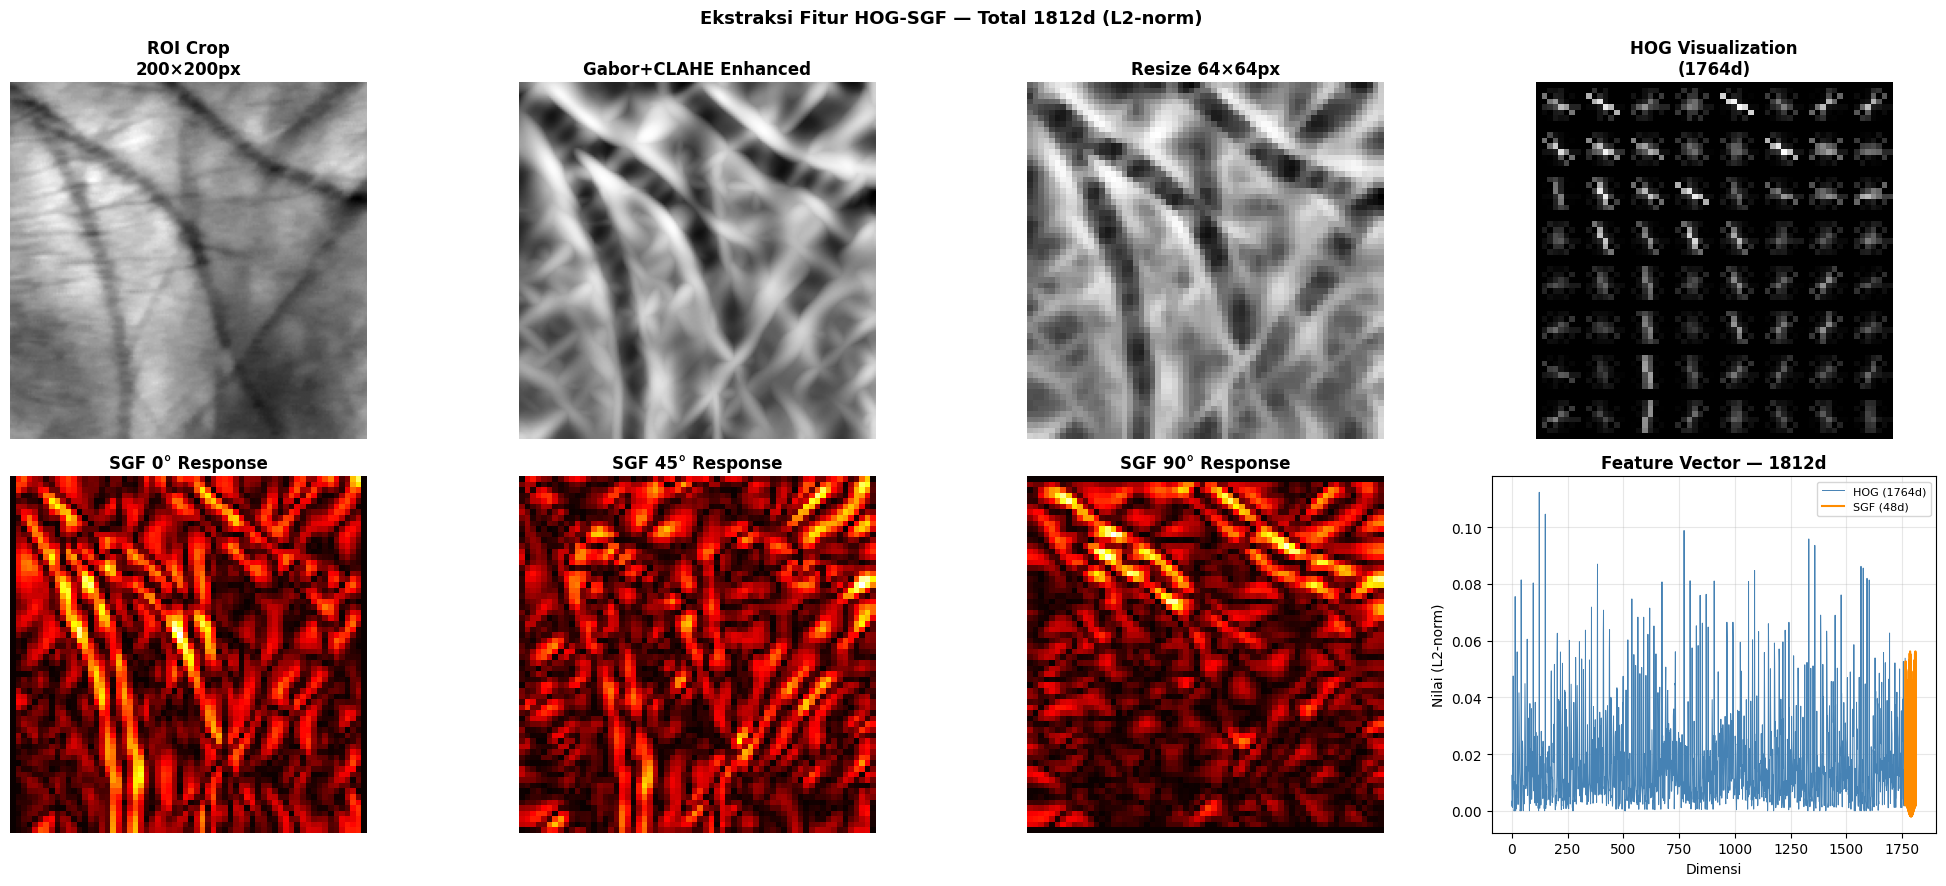

✓ HOG-SGF feature dim: 1812 (1764d HOG + 48d SGF)


In [95]:
def extract_hog_sgf(img_gray, hog_orient=None, hog_pixels=None,
                    hog_cells=None, visualize=False):
    """
    Ekstraksi fitur HOG-SGF sesuai paper.
 
    Dimensi output:
      HOG : 1764 dim  (default config)
      SGF :   48 dim  (24 sudut × mean + std)
      Total: 1812 dim, di-L2-normalize
 
    Args:
        visualize : jika True, kembalikan juga hog_img, img_64, Ix, Iy
    """
    orient = hog_orient or Config.HOG_ORIENT
    pixels = hog_pixels or Config.HOG_PIXELS
    cells  = hog_cells  or Config.HOG_CELLS
 
    img_64 = cv2.resize(img_gray, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
 
    # ── HOG ──
    if visualize:
        hog_feat, hog_img = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels), cells_per_block=(cells, cells),
            block_norm='L2', visualize=True
        )
    else:
        hog_feat = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels), cells_per_block=(cells, cells),
            block_norm='L2', visualize=False
        )
        hog_img = None
 
    # ── SGF ──
    img_f = img_64.astype(np.float32)
    Ix    = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    Iy    = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)
 
    sgf_feats = []
    for theta in Config.SGF_ANGLES:
        FR = np.cos(theta) * Ix + np.sin(theta) * Iy
        sgf_feats.extend([np.mean(FR), np.std(FR)])
 
    sgf_feat = np.array(sgf_feats, dtype=np.float32)   # 48 dim
 
    # ── Gabung + L2 normalize ──
    hog_norm = hog_feat / (np.linalg.norm(hog_feat) + 1e-8)
    sgf_norm = sgf_feat / (np.linalg.norm(sgf_feat) + 1e-8)
    # Bobot: HOG 80%, SGF 20% → bisa di-tune nanti
    combined = np.concatenate([hog_norm * 0.8, sgf_norm * 0.2])
    # Final L2-normalize keseluruhan
    norm = np.linalg.norm(combined)
    if norm > 0:
        combined = combined / norm

 
    if visualize:
        return combined, hog_img, img_64, Ix, Iy
    return combined
 
 
# ── Visualisasi ekstraksi fitur pada 1 sample ──
if samples:
    dog_s = normalize_illumination(roi_s)   # DoG dulu
    enh_s = enhance_gabor(roi_s, use_dog=True)  # Gabor+DoG
    feat_s, hog_img_s, img64_s, Ix_s, Iy_s = extract_hog_sgf(enh_s, visualize=True)
 
    hog_dim = len(feat_s) - len(Config.SGF_ANGLES) * 2
    sgf_dim = len(Config.SGF_ANGLES) * 2
 
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(f'Ekstraksi Fitur HOG-SGF — Total {len(feat_s)}d (L2-norm)', fontsize=13, fontweight='bold')
 
    # Row 0: tahapan gambar
    axes[0, 0].imshow(roi_s, cmap='gray')
    axes[0, 0].set_title(f'ROI Crop\n{Config.ROI_SIZE}×{Config.ROI_SIZE}px', fontweight='bold')
    axes[0, 0].axis('off')
 
    axes[0, 1].imshow(enh_s, cmap='gray')
    axes[0, 1].set_title('Gabor+CLAHE Enhanced', fontweight='bold')
    axes[0, 1].axis('off')
 
    axes[0, 2].imshow(img64_s, cmap='gray')
    axes[0, 2].set_title(f'Resize {Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}px', fontweight='bold')
    axes[0, 2].axis('off')
 
    axes[0, 3].imshow(hog_img_s, cmap='gray')
    axes[0, 3].set_title(f'HOG Visualization\n({hog_dim}d)', fontweight='bold')
    axes[0, 3].axis('off')
 
    # Row 1: SGF orientasi + feature vector
    sgf_angles_vis = [0, np.pi/4, np.pi/2]
    sgf_labels_vis = ['SGF 0°', 'SGF 45°', 'SGF 90°']
    for col, (theta, lbl) in enumerate(zip(sgf_angles_vis, sgf_labels_vis)):
        FR   = np.cos(theta) * Ix_s + np.sin(theta) * Iy_s
        FR_n = cv2.normalize(np.abs(FR), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        axes[1, col].imshow(FR_n, cmap='hot')
        axes[1, col].set_title(f'{lbl} Response', fontweight='bold')
        axes[1, col].axis('off')
 
    axes[1, 3].plot(feat_s[:hog_dim], lw=0.7, color='steelblue', label=f'HOG ({hog_dim}d)')
    axes[1, 3].plot(range(hog_dim, hog_dim + sgf_dim),
                    feat_s[hog_dim:], lw=1.5, color='darkorange', label=f'SGF ({sgf_dim}d)')
    axes[1, 3].set_title(f'Feature Vector — {len(feat_s)}d', fontweight='bold')
    axes[1, 3].legend(fontsize=8)
    axes[1, 3].grid(True, alpha=0.3)
    axes[1, 3].set_xlabel('Dimensi')
    axes[1, 3].set_ylabel('Nilai (L2-norm)')
 
    plt.tight_layout()
    plt.show()
    print(f'✓ HOG-SGF feature dim: {len(feat_s)} ({hog_dim}d HOG + {sgf_dim}d SGF)')

### BAGIAN 5 — LOAD DATASET + AUGMENTASI


[5] Loading dataset dengan augmentasi...
  Total file    : 3000
  Augmentasi    : 3× per gambar
  Total efektif : 12000 samples


Loading + Augmenting: 100%|██████████| 3000/3000 [04:26<00:00, 11.27it/s]



✓ Dataset loaded:
  Original   : 3000 samples
  Augmented  : 9000 samples
  Total      : 12000 samples | 300 subjects
  Feature dim: 1812

[5b] Membuat template dan query split...
  Template (train) : 900 (300 subjects × 3 foto)
  Query    (test)  : 2100 (300 subjects × 7 foto)
  Aug in train     : 9000
  Total train      : 9900
  Overlap subjects : 300 (harus 300!)


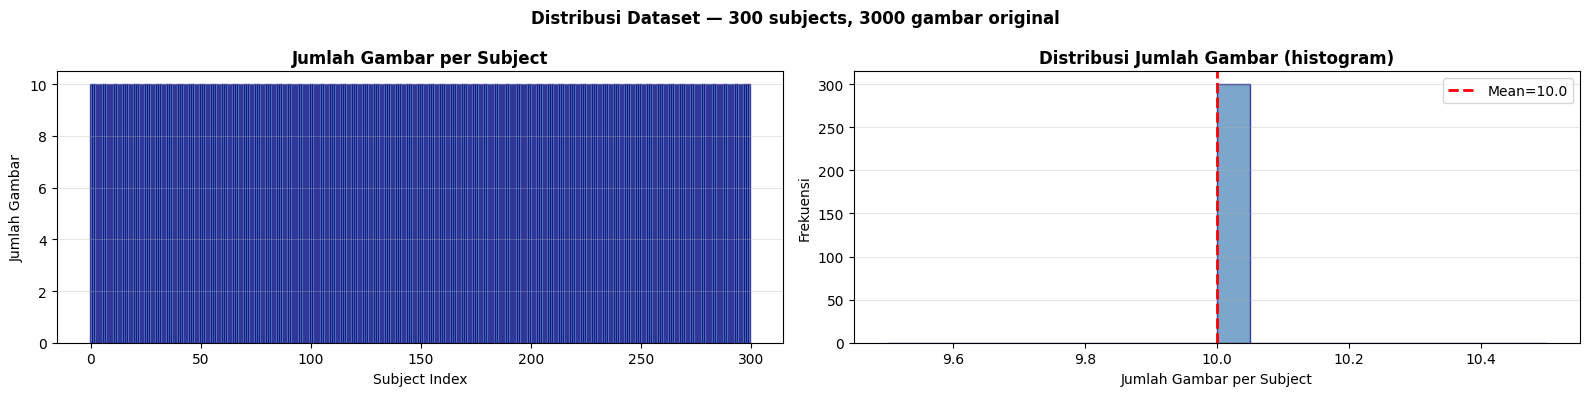

  Min per kelas: 10, Max: 10, Rata-rata: 10.0


In [96]:
### BAGIAN 5 — LOAD DATASET + AUGMENTASI

def parse_label(fname):
    """
    Ekstrak subject ID dari nama file.
    Format yang didukung: subject_282_left_hand_08.tiff
    Fallback: bagian pertama nama file.
    """
    name  = os.path.splitext(fname)[0]
    parts = name.split('_')
    for part in parts:
        if part.isdigit():
            return part
    return parts[0]


def load_dataset_with_augmentation(dataset_path, verbose=True,
                                   hog_orient=None, hog_pixels=None, hog_cells=None):
    """
    Load dataset dari folder, ekstrak fitur HOG-SGF, dan augmentasi data.

    Strategi augmentasi:
      - Setiap ROI di-augment 3 kali → total dataset 4× ukuran asli
      - Augmentasi HANYA dilakukan pada training set
      - Label augmented identik dengan original (orang yang sama)

    Returns:
        X            : feature matrix (n_samples × n_features)
        y            : label array
        is_augmented : boolean array, True = sample hasil augmentasi
    """
    features, labels, is_augmented = [], [], []

    exts  = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
    files = [f for f in os.listdir(dataset_path) if f.lower().endswith(exts)]

    if verbose:
        print(f'  Total file    : {len(files)}')
        print(f'  Augmentasi    : 3× per gambar')
        print(f'  Total efektif : {len(files) * 4} samples')

    for fname in tqdm(files, desc='Loading + Augmenting', disable=not verbose):
        img = cv2.imread(os.path.join(dataset_path, fname))
        if img is None:
            continue

        label    = parse_label(fname)
        roi, _   = detect_palm_opencv(img)

        # ✅ use_dog=True konsisten dengan pipeline
        enhanced = enhance_gabor(roi, use_dog=True)

        # Original
        feat = extract_hog_sgf(enhanced, hog_orient=hog_orient,
                                hog_pixels=hog_pixels, hog_cells=hog_cells)
        features.append(feat); labels.append(label); is_augmented.append(False)

        # Augmented (3 variasi)
        for aug_roi in augment_roi(roi, n_aug=3):
            aug_feat = extract_hog_sgf(enhance_gabor(aug_roi, use_dog=True),
                                       hog_orient=hog_orient,
                                       hog_pixels=hog_pixels,
                                       hog_cells=hog_cells)
            features.append(aug_feat); labels.append(label); is_augmented.append(True)

    X            = np.array(features)
    y            = np.array(labels)
    is_augmented = np.array(is_augmented)

    if verbose:
        orig_count = (~is_augmented).sum()
        aug_count  = is_augmented.sum()
        print(f'\n✓ Dataset loaded:')
        print(f'  Original   : {orig_count} samples')
        print(f'  Augmented  : {aug_count} samples')
        print(f'  Total      : {len(X)} samples | {len(np.unique(y))} subjects')
        print(f'  Feature dim: {X.shape[1]}')

    return X, y, is_augmented


# ── Load dataset ──
print('\n[5] Loading dataset dengan augmentasi...')
X, y, is_aug = load_dataset_with_augmentation(Config.DATASET_PATH)

# ── Split: 3 gambar per subject = template, sisanya = query ──
# Strategi ini memastikan semua 300 subject ada di train (template) DAN test (query)
# sehingga 1:1 verification bisa disimulasikan dengan benar di Cell 7
print('\n[5b] Membuat template dan query split...')

X_orig, y_orig = X[~is_aug], y[~is_aug]

template_indices = []
query_indices    = []

np.random.seed(42)
for subj in np.unique(y_orig):
    subj_idx = np.where(y_orig == subj)[0].copy()
    np.random.shuffle(subj_idx)
    template_indices.extend(subj_idx[:3])   # 3 foto = template (simulasi registrasi)
    query_indices.extend(subj_idx[3:])      # 7 foto = query (simulasi absensi)

template_indices = np.array(template_indices)
query_indices    = np.array(query_indices)

X_template = X_orig[template_indices]; y_template = y_orig[template_indices]
X_query    = X_orig[query_indices];    y_query    = y_orig[query_indices]

# Augmented hanya dari template (simulasi augmentasi saat registrasi)
y_aug    = y[is_aug]
X_aug    = X[is_aug]
mask_aug = np.array([lbl in set(y_template) for lbl in y_aug])

X_train = np.vstack([X_template, X_aug[mask_aug]])
y_train = np.concatenate([y_template, y_aug[mask_aug]])

X_test = X_query
y_test = y_query

print(f'  Template (train) : {len(X_template)} ({len(np.unique(y_template))} subjects × 3 foto)')
print(f'  Query    (test)  : {len(X_test)} ({len(np.unique(y_test))} subjects × 7 foto)')
print(f'  Aug in train     : {mask_aug.sum()}')
print(f'  Total train      : {len(X_train)}')
print(f'  Overlap subjects : {len(set(y_template) & set(y_test))} (harus 300!)')


# ── Visualisasi distribusi dataset ──
unique_labels, counts = np.unique(y_orig, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle(f'Distribusi Dataset — {len(unique_labels)} subjects, {len(y_orig)} gambar original',
             fontsize=12, fontweight='bold')

axes[0].bar(range(len(unique_labels)), counts, color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].set_title('Jumlah Gambar per Subject', fontweight='bold')
axes[0].set_xlabel('Subject Index'); axes[0].set_ylabel('Jumlah Gambar')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(counts, bins=20, color='steelblue', edgecolor='navy', alpha=0.7)
axes[1].set_title('Distribusi Jumlah Gambar (histogram)', fontweight='bold')
axes[1].set_xlabel('Jumlah Gambar per Subject'); axes[1].set_ylabel('Frekuensi')
axes[1].axvline(counts.mean(), color='red', ls='--', lw=2, label=f'Mean={counts.mean():.1f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print(f'  Min per kelas: {counts.min()}, Max: {counts.max()}, Rata-rata: {counts.mean():.1f}')

### BAGIAN 6 — NORMALISASI & PCA


[6] StandardScaler + PCA...
  Komponen   : 588 (dari 1812 dim)
  Variance   : 0.9901 (99.01%)
  Reduksi    : 1812 → 588 (67.5%)


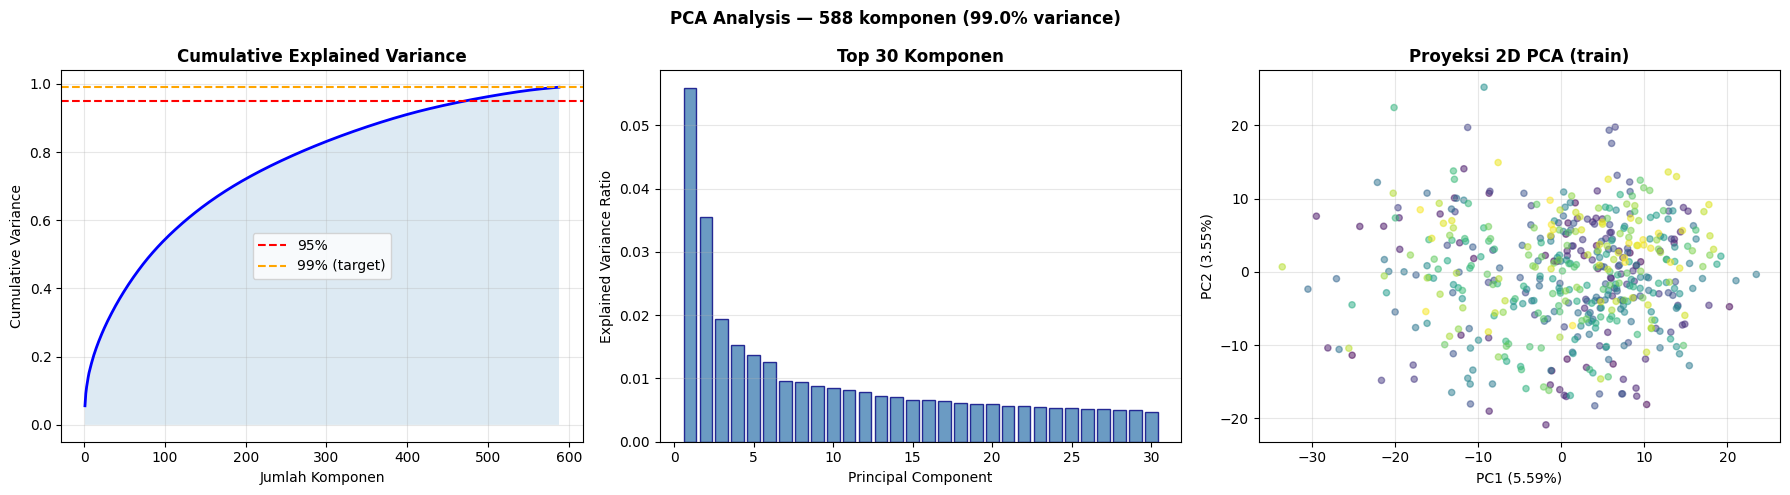

In [97]:
print('\n[6] StandardScaler + PCA...')
 
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
pca         = PCA(n_components=Config.PCA_VARIANCE, whiten=False, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
 
n_comp    = pca.n_components_
var_total = np.sum(pca.explained_variance_ratio_)
print(f'  Komponen   : {n_comp} (dari {X_train.shape[1]} dim)')
print(f'  Variance   : {var_total:.4f} ({var_total*100:.2f}%)')
print(f'  Reduksi    : {X_train.shape[1]} → {n_comp} ({(1 - n_comp/X_train.shape[1])*100:.1f}%)')
 
 
# ── Visualisasi PCA ──
cumsum = np.cumsum(pca.explained_variance_ratio_)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'PCA Analysis — {n_comp} komponen ({var_total*100:.1f}% variance)',
             fontsize=12, fontweight='bold')
 
# Cumulative variance
axes[0].plot(range(1, n_comp + 1), cumsum, 'b-', lw=2)
axes[0].axhline(0.95, color='r', ls='--', label='95%')
axes[0].axhline(Config.PCA_VARIANCE, color='orange', ls='--',
                label=f'{Config.PCA_VARIANCE*100:.0f}% (target)')
axes[0].fill_between(range(1, n_comp + 1), cumsum, alpha=0.15)
axes[0].set_xlabel('Jumlah Komponen'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('Cumulative Explained Variance', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
# Top-30 komponen
axes[1].bar(range(1, min(31, n_comp + 1)), pca.explained_variance_ratio_[:30],
            color='steelblue', edgecolor='navy', alpha=0.8)
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Top 30 Komponen', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
 
# Scatter 2D
n_vis = min(500, len(X_train_pca))
axes[2].scatter(X_train_pca[:n_vis, 0], X_train_pca[:n_vis, 1],
                c=range(n_vis), cmap='viridis', s=20, alpha=0.5)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[2].set_title('Proyeksi 2D PCA (train)', fontweight='bold')
axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

### BAGIAN 7 — SWEEP THRESHOLD → THRESHOLD OPTIMAL (1:1 Verification)


[7] Menyiapkan positive & negative pairs untuk 1:1 verification...
  Positive pairs : 2100
  Negative pairs : 2100
  Positive sim   : mean=0.4816, std=0.2402
  Negative sim   : mean=0.0479, std=0.0812
  Separability   : 1.8057

  Sweeping threshold 0.30–0.99...


Sweeping threshold: 100%|██████████| 94/94 [00:00<00:00, 25964.08it/s]


  ✓ Threshold optimal (EER point):
    Threshold : 0.1400
    FAR       : 0.1181  (orang lain diterima)
    FRR       : 0.1276  (orang asli ditolak)
    EER       : 0.1229
    Accuracy  : 0.8771
    F1        : 0.8766

  ✓ Threshold alternatif (F1 terbaik):
    Threshold : 0.1700
    FAR       : 0.0700
    FRR       : 0.1595
    F1        : 0.8799
    Accuracy  : 0.8852


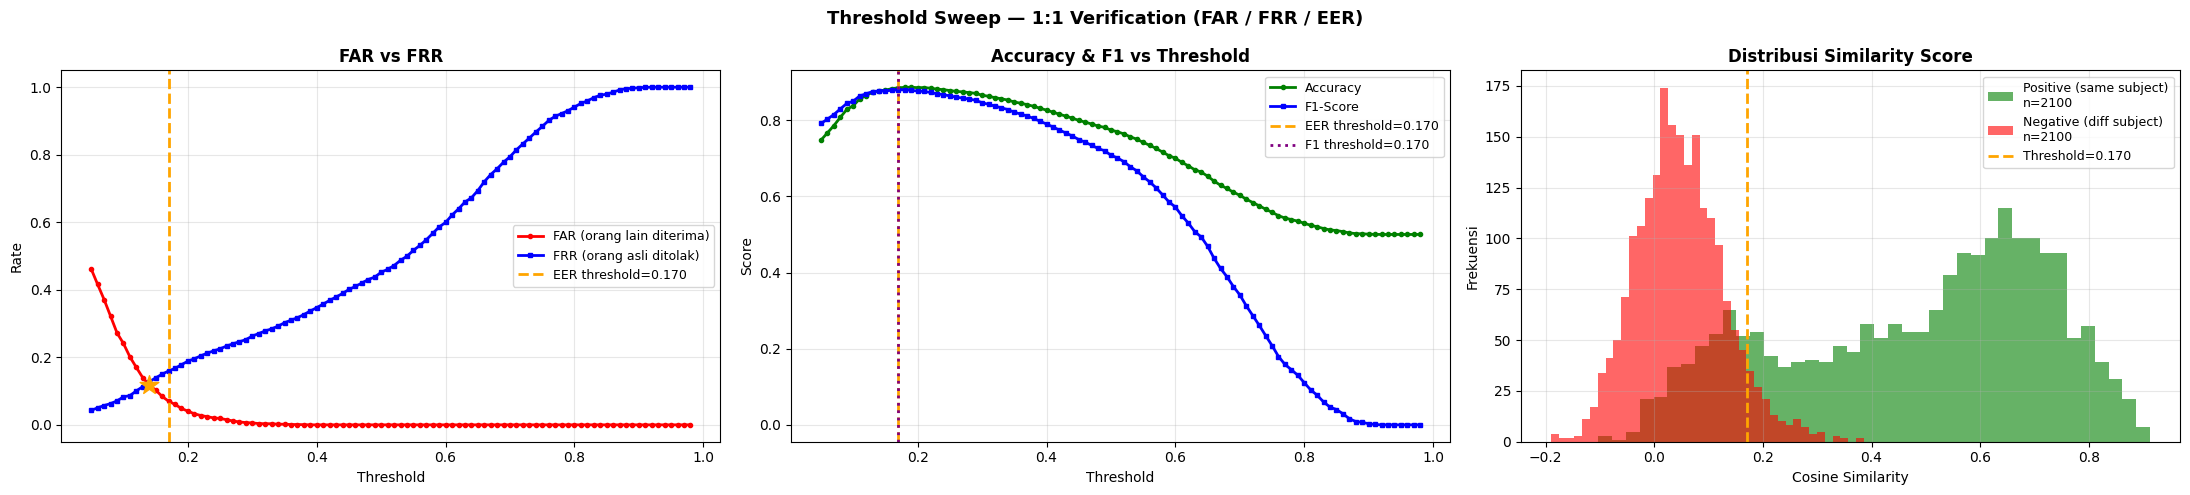

In [98]:
### BAGIAN 7 — SWEEP THRESHOLD → THRESHOLD OPTIMAL (1:1 Verification)

print('\n[7] Menyiapkan positive & negative pairs untuk 1:1 verification...')

np.random.seed(42)

positive_scores = []  # same subject: query vs template milik sendiri
negative_scores = []  # diff subject: query vs template milik orang lain

# Simulasi persis seperti Laravel:
# - Setiap test sample = 1 foto absensi
# - Dibandingkan dengan MAX similarity dari 3 template milik subject yang sama
# - Negative: dibandingkan dengan 3 template milik subject lain (random)

for i, (x_test, y_t) in enumerate(zip(X_test_pca, y_test)):

    # ── Positive pair: ambil dari X_template (original, bukan augmented) ──
    # Transform X_template ke PCA space
    same_template_idx = np.where(y_template == y_t)[0]  # pasti ada 3
    templates_pca     = pca.transform(scaler.transform(X_template[same_template_idx]))
    sims_positive     = cosine_similarity([x_test], templates_pca)[0]
    positive_scores.append(sims_positive.max())

    # ── Negative pair: ambil template dari subject lain ──
    diff_subjects  = [s for s in np.unique(y_template) if s != y_t]
    rand_subject   = np.random.choice(diff_subjects)
    diff_templ_idx = np.where(y_template == rand_subject)[0][:3]
    neg_templ_pca  = pca.transform(scaler.transform(X_template[diff_templ_idx]))
    sims_negative  = cosine_similarity([x_test], neg_templ_pca)[0]
    negative_scores.append(sims_negative.max())

positive_scores = np.array(positive_scores)
negative_scores = np.array(negative_scores)

print(f'  Positive pairs : {len(positive_scores)}')
print(f'  Negative pairs : {len(negative_scores)}')
print(f'  Positive sim   : mean={positive_scores.mean():.4f}, std={positive_scores.std():.4f}')
print(f'  Negative sim   : mean={negative_scores.mean():.4f}, std={negative_scores.std():.4f}')
print(f'  Separability   : {(positive_scores.mean() - negative_scores.mean()) / positive_scores.std():.4f}')
# Separability > 1.0 = bagus, > 2.0 = sangat bagus

# ── Sweep threshold ──
print('\n  Sweeping threshold 0.30–0.99...')

thresholds_sweep = np.arange(0.05, 0.99, 0.01)
results_sweep    = []

for th in tqdm(thresholds_sweep, desc='Sweeping threshold'):
    tp = np.sum(positive_scores >= th)  # orang asli diterima ✅
    fn = np.sum(positive_scores <  th)  # orang asli ditolak ❌
    fp = np.sum(negative_scores >= th)  # orang lain diterima ❌
    tn = np.sum(negative_scores <  th)  # orang lain ditolak ✅

    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # False Accept Rate
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # False Reject Rate
    acc = (tp + tn) / (tp + tn + fp + fn)

    # F1 untuk positive class
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    results_sweep.append({
        'threshold': th,
        'far'      : far,
        'frr'      : frr,
        'eer_diff' : abs(far - frr),
        'accuracy' : acc,
        'f1'       : f1,
        'precision': precision,
        'recall'   : recall,
    })

# ── Threshold optimal = EER point (FAR ≈ FRR) ──
best_eer = min(results_sweep, key=lambda r: r['eer_diff'])

# ── Threshold alternatif = F1 terbaik ──
best_f1  = max(results_sweep, key=lambda r: r['f1'])

THRESHOLD_OPTIMAL = best_f1['threshold']

print(f'\n  ✓ Threshold optimal (EER point):')
print(f'    Threshold : {best_eer["threshold"]:.4f}')
print(f'    FAR       : {best_eer["far"]:.4f}  (orang lain diterima)')
print(f'    FRR       : {best_eer["frr"]:.4f}  (orang asli ditolak)')
print(f'    EER       : {(best_eer["far"] + best_eer["frr"]) / 2:.4f}')
print(f'    Accuracy  : {best_eer["accuracy"]:.4f}')
print(f'    F1        : {best_eer["f1"]:.4f}')

print(f'\n  ✓ Threshold alternatif (F1 terbaik):')
print(f'    Threshold : {best_f1["threshold"]:.4f}')
print(f'    FAR       : {best_f1["far"]:.4f}')
print(f'    FRR       : {best_f1["frr"]:.4f}')
print(f'    F1        : {best_f1["f1"]:.4f}')
print(f'    Accuracy  : {best_f1["accuracy"]:.4f}')


# ── Visualisasi ──
ths  = [r['threshold'] for r in results_sweep]
fars = [r['far']       for r in results_sweep]
frrs = [r['frr']       for r in results_sweep]
accs = [r['accuracy']  for r in results_sweep]
f1s  = [r['f1']        for r in results_sweep]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Threshold Sweep — 1:1 Verification (FAR / FRR / EER)', fontsize=13, fontweight='bold')

# ── Kiri: FAR vs FRR (kurva biometric standar) ──
axes[0].plot(ths, fars, 'r-o',  ms=3, lw=2, label='FAR (orang lain diterima)')
axes[0].plot(ths, frrs, 'b-s',  ms=3, lw=2, label='FRR (orang asli ditolak)')
axes[0].axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2,
                label=f'EER threshold={THRESHOLD_OPTIMAL:.3f}')
axes[0].scatter([best_eer['threshold']], [best_eer['far']],
                color='orange', s=200, zorder=5, marker='*')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Rate')
axes[0].set_title('FAR vs FRR', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# ── Tengah: Accuracy & F1 ──
axes[1].plot(ths, accs, 'g-o', ms=3, lw=2, label='Accuracy')
axes[1].plot(ths, f1s,  'b-s', ms=3, lw=2, label='F1-Score')
axes[1].axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2,
                label=f'EER threshold={THRESHOLD_OPTIMAL:.3f}')
axes[1].axvline(best_f1['threshold'], color='purple', ls=':', lw=2,
                label=f'F1 threshold={best_f1["threshold"]:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Accuracy & F1 vs Threshold', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# ── Kanan: Distribusi similarity score ──
axes[2].hist(positive_scores, bins=40, alpha=0.6, color='green',
             label=f'Positive (same subject)\nn={len(positive_scores)}')
axes[2].hist(negative_scores, bins=40, alpha=0.6, color='red',
             label=f'Negative (diff subject)\nn={len(negative_scores)}')
axes[2].axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2,
                label=f'Threshold={THRESHOLD_OPTIMAL:.3f}')
axes[2].set_xlabel('Cosine Similarity'); axes[2].set_ylabel('Frekuensi')
axes[2].set_title('Distribusi Similarity Score', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== DIAGNOSA: PCA tanpa whiten ===
  Positive sim : mean=0.4816, std=0.2402
  Negative sim : mean=0.0479, std=0.0812
  Separability : 1.8057


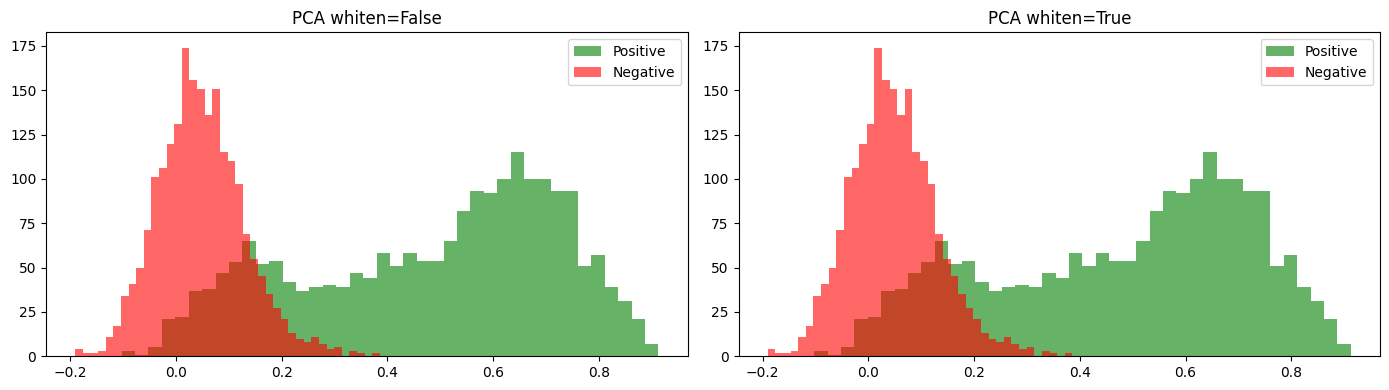

In [99]:
# Cell diagnosa cepat — jalankan sebagai cell baru
print("=== DIAGNOSA: PCA tanpa whiten ===")

pca_nowhiten = PCA(n_components=Config.PCA_VARIANCE, whiten=False, random_state=42)
X_train_pca2 = pca_nowhiten.fit_transform(X_train_sc)
X_test_pca2  = pca_nowhiten.transform(X_test_sc)

pos2, neg2 = [], []
np.random.seed(42)
for x_test, y_t in zip(X_test_pca2, y_test):
    same_idx = np.where(y_template == y_t)[0]
    tmpl_pca = pca_nowhiten.transform(scaler.transform(X_template[same_idx]))
    pos2.append(cosine_similarity([x_test], tmpl_pca)[0].max())

    diff_subj  = np.random.choice([s for s in np.unique(y_template) if s != y_t])
    diff_idx   = np.where(y_template == diff_subj)[0][:3]
    neg_pca    = pca_nowhiten.transform(scaler.transform(X_template[diff_idx]))
    neg2.append(cosine_similarity([x_test], neg_pca)[0].max())

pos2 = np.array(pos2); neg2 = np.array(neg2)
print(f'  Positive sim : mean={pos2.mean():.4f}, std={pos2.std():.4f}')
print(f'  Negative sim : mean={neg2.mean():.4f}, std={neg2.std():.4f}')
print(f'  Separability : {(pos2.mean()-neg2.mean())/pos2.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(pos2, bins=40, alpha=0.6, color='green', label='Positive')
axes[0].hist(neg2, bins=40, alpha=0.6, color='red',   label='Negative')
axes[0].set_title('PCA whiten=False'); axes[0].legend()

# Bandingkan dengan whiten=True
axes[1].hist(positive_scores, bins=40, alpha=0.6, color='green', label='Positive')
axes[1].hist(negative_scores, bins=40, alpha=0.6, color='red',   label='Negative')
axes[1].set_title('PCA whiten=True'); axes[1].legend()

plt.tight_layout(); plt.show()

### BAGIAN 8 — EVALUASI FINAL


[8] Evaluasi final dengan BEST_PARAMS...
  Parameter:
    hog_orient      : 9
    hog_pixels      : 8
    hog_cells       : 2
    pca_variance    : 0.99
    threshold       : 0.17000000000000004

  HASIL EVALUASI FINAL — 1:1 Verification
  Threshold          : 0.1700
  PCA n_components   : 588
  Variance retained  : 0.9901

  Positive pairs     : 2100 (orang asli)
  Negative pairs     : 2100 (orang lain)

  TP (diterima benar): 1765
  TN (ditolak benar) : 1953
  FP (orang lain masuk): 147
  FN (orang asli ditolak): 335

  FAR (False Accept) : 0.0700 (7.00%)
  FRR (False Reject) : 0.1595 (15.95%)
  EER                : 0.1148 (11.48%)

  Accuracy           : 0.8852 (88.52%)
  Precision          : 0.9231
  Recall             : 0.8405
  F1-Score           : 0.8799


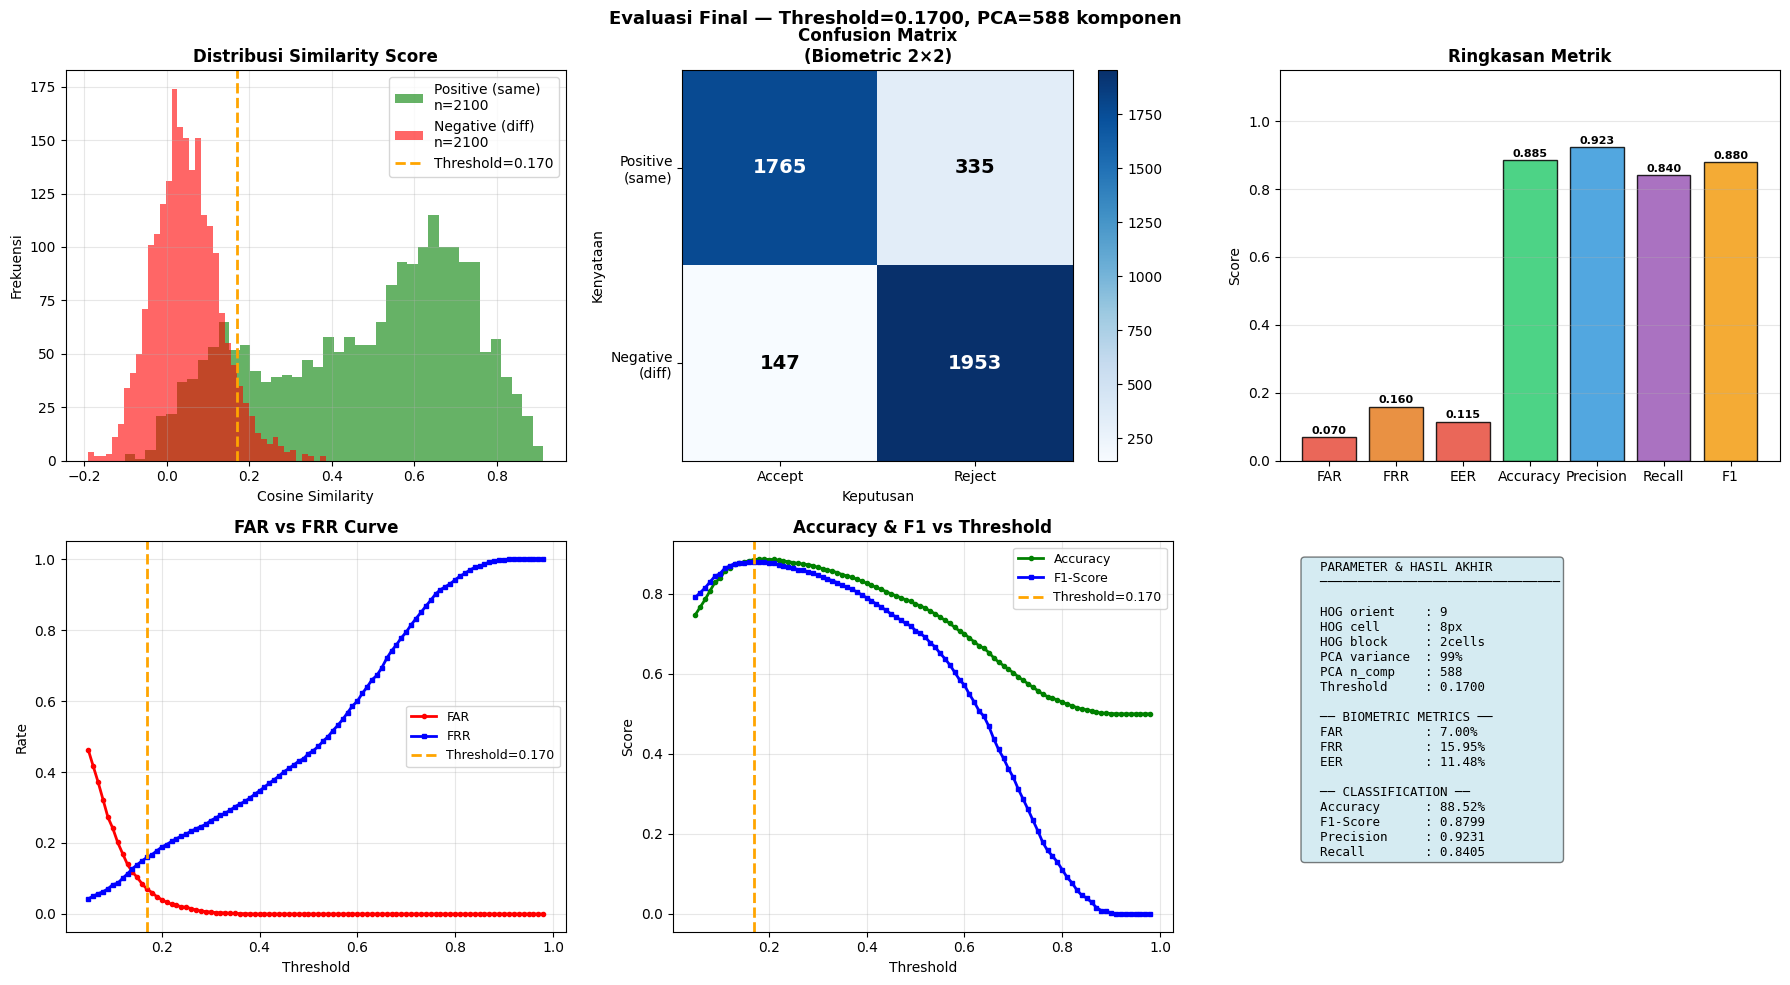

In [100]:
### BAGIAN 8 — EVALUASI FINAL

BEST_PARAMS = {
    'hog_orient'  : Config.HOG_ORIENT,
    'hog_pixels'  : Config.HOG_PIXELS,
    'hog_cells'   : Config.HOG_CELLS,
    'pca_variance': Config.PCA_VARIANCE,
    'threshold'   : THRESHOLD_OPTIMAL,
}

print('\n[8] Evaluasi final dengan BEST_PARAMS...')
print('  Parameter:')
for k, v in BEST_PARAMS.items():
    print(f'    {k:<15} : {v}')

# ── Evaluasi 1:1 verification menggunakan positive/negative scores dari Cell 7 ──
th = THRESHOLD_OPTIMAL

tp = np.sum(positive_scores >= th)
fn = np.sum(positive_scores <  th)
fp = np.sum(negative_scores >= th)
tn = np.sum(negative_scores <  th)

far      = fp / (fp + tn) if (fp + tn) > 0 else 0.0
frr      = fn / (fn + tp) if (fn + tp) > 0 else 0.0
eer      = (far + frr) / 2
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print('\n' + '='*60)
print('  HASIL EVALUASI FINAL — 1:1 Verification')
print('='*60)
print(f'  Threshold          : {th:.4f}')
print(f'  PCA n_components   : {pca.n_components_}')
print(f'  Variance retained  : {np.sum(pca.explained_variance_ratio_):.4f}')
print()
print(f'  Positive pairs     : {len(positive_scores)} (orang asli)')
print(f'  Negative pairs     : {len(negative_scores)} (orang lain)')
print()
print(f'  TP (diterima benar): {tp}')
print(f'  TN (ditolak benar) : {tn}')
print(f'  FP (orang lain masuk): {fp}')
print(f'  FN (orang asli ditolak): {fn}')
print()
print(f'  FAR (False Accept) : {far:.4f} ({far*100:.2f}%)')
print(f'  FRR (False Reject) : {frr:.4f} ({frr*100:.2f}%)')
print(f'  EER                : {eer:.4f} ({eer*100:.2f}%)')
print()
print(f'  Accuracy           : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  Precision          : {precision:.4f}')
print(f'  Recall             : {recall:.4f}')
print(f'  F1-Score           : {f1:.4f}')
print('='*60)


# ── Visualisasi evaluasi ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Evaluasi Final — Threshold={th:.4f}, PCA={pca.n_components_} komponen',
             fontsize=13, fontweight='bold')

# 1. Distribusi similarity score
axes[0, 0].hist(positive_scores, bins=40, alpha=0.6, color='green',
                label=f'Positive (same)\nn={len(positive_scores)}')
axes[0, 0].hist(negative_scores, bins=40, alpha=0.6, color='red',
                label=f'Negative (diff)\nn={len(negative_scores)}')
axes[0, 0].axvline(th, color='orange', ls='--', lw=2, label=f'Threshold={th:.3f}')
axes[0, 0].set_xlabel('Cosine Similarity'); axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].set_title('Distribusi Similarity Score', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Confusion matrix 2x2 (biometric standard)
cm2 = np.array([[tp, fn], [fp, tn]])
im  = axes[0, 1].imshow(cm2, cmap='Blues')
axes[0, 1].set_xticks([0, 1]); axes[0, 1].set_yticks([0, 1])
axes[0, 1].set_xticklabels(['Accept', 'Reject'])
axes[0, 1].set_yticklabels(['Positive\n(same)', 'Negative\n(diff)'])
for i in range(2):
    for j in range(2):
        axes[0, 1].text(j, i, cm2[i, j], ha='center', va='center',
                        fontsize=14, fontweight='bold',
                        color='white' if cm2[i, j] > cm2.max()/2 else 'black')
plt.colorbar(im, ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix\n(Biometric 2×2)', fontweight='bold')
axes[0, 1].set_xlabel('Keputusan'); axes[0, 1].set_ylabel('Kenyataan')

# 3. Metrics bar chart
metric_names = ['FAR', 'FRR', 'EER', 'Accuracy', 'Precision', 'Recall', 'F1']
metric_vals  = [far, frr, eer, accuracy, precision, recall, f1]
colors_m     = ['#e74c3c', '#e67e22', '#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']
bars = axes[0, 2].bar(metric_names, metric_vals, color=colors_m, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, metric_vals):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0, 2].set_ylim(0, 1.15)
axes[0, 2].set_title('Ringkasan Metrik', fontweight='bold')
axes[0, 2].set_ylabel('Score'); axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. FAR vs FRR dari sweep Cell 7
axes[1, 0].plot(ths, fars, 'r-o', ms=3, lw=2, label='FAR')
axes[1, 0].plot(ths, frrs, 'b-s', ms=3, lw=2, label='FRR')
axes[1, 0].axvline(th, color='orange', ls='--', lw=2, label=f'Threshold={th:.3f}')
axes[1, 0].set_xlabel('Threshold'); axes[1, 0].set_ylabel('Rate')
axes[1, 0].set_title('FAR vs FRR Curve', fontweight='bold')
axes[1, 0].legend(fontsize=9); axes[1, 0].grid(True, alpha=0.3)

# 5. Accuracy & F1 dari sweep Cell 7
axes[1, 1].plot(ths, accs, 'g-o', ms=3, lw=2, label='Accuracy')
axes[1, 1].plot(ths, f1s,  'b-s', ms=3, lw=2, label='F1-Score')
axes[1, 1].axvline(th, color='orange', ls='--', lw=2, label=f'Threshold={th:.3f}')
axes[1, 1].set_xlabel('Threshold'); axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Accuracy & F1 vs Threshold', fontweight='bold')
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(True, alpha=0.3)

# 6. Info box ringkasan
axes[1, 2].axis('off')
axes[1, 2].text(0.05, 0.95,
    f'  PARAMETER & HASIL AKHIR\n  {"─"*32}\n\n'
    f'  HOG orient    : {BEST_PARAMS["hog_orient"]}\n'
    f'  HOG cell      : {BEST_PARAMS["hog_pixels"]}px\n'
    f'  HOG block     : {BEST_PARAMS["hog_cells"]}cells\n'
    f'  PCA variance  : {BEST_PARAMS["pca_variance"]*100:.0f}%\n'
    f'  PCA n_comp    : {pca.n_components_}\n'
    f'  Threshold     : {th:.4f}\n\n'
    f'  ── BIOMETRIC METRICS ──\n'
    f'  FAR           : {far*100:.2f}%\n'
    f'  FRR           : {frr*100:.2f}%\n'
    f'  EER           : {eer*100:.2f}%\n\n'
    f'  ── CLASSIFICATION ──\n'
    f'  Accuracy      : {accuracy*100:.2f}%\n'
    f'  F1-Score      : {f1:.4f}\n'
    f'  Precision     : {precision:.4f}\n'
    f'  Recall        : {recall:.4f}',
    transform=axes[1, 2].transAxes, fontsize=9, va='top', fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
)

plt.tight_layout()
plt.show()

### BAGIAN 9 — SIMPAN MODEL

In [101]:
### BAGIAN 9 — SIMPAN MODEL

print('\n[9] Menyimpan model...')

# ✅ Pakai scaler dan pca dari Cell 6 (bukan scaler_best/pca_best yang sudah tidak ada)
joblib.dump(scaler,            os.path.join(Config.MODELS_DIR, 'scaler.pkl'))
joblib.dump(pca,               os.path.join(Config.MODELS_DIR, 'pca.pkl'))
joblib.dump(THRESHOLD_OPTIMAL, os.path.join(Config.MODELS_DIR, 'threshold.pkl'))

# ✅ best_config menggunakan variabel dari Cell 8 yang benar
best_config = {
    # Parameter
    'hog_orient'    : int(BEST_PARAMS['hog_orient']),
    'hog_pixels'    : int(BEST_PARAMS['hog_pixels']),
    'hog_cells'     : int(BEST_PARAMS['hog_cells']),
    'pca_variance'  : float(BEST_PARAMS['pca_variance']),
    'pca_n_comp'    : int(pca.n_components_),
    'pca_whiten'    : False,
    'threshold'     : float(THRESHOLD_OPTIMAL),
    'use_dog'       : True,
    'gabor_ksize'   : int(Config.GABOR_KSIZE),
    'gabor_lambda'  : float(Config.GABOR_LAMBDA),

    # Metrik biometric (dari Cell 8)
    'far'           : float(far),
    'frr'           : float(frr),
    'eer'           : float(eer),

    # Metrik klasifikasi (dari Cell 8)
    'accuracy'      : float(accuracy),
    'f1'            : float(f1),
    'precision'     : float(precision),
    'recall'        : float(recall),

    # Info dataset
    'n_subjects'    : int(len(np.unique(y))),
    'n_template'    : int(len(X_template)),
    'n_query'       : int(len(X_query)),
    'feature_dim'   : int(X.shape[1]),
    'positive_mean' : float(positive_scores.mean()),
    'negative_mean' : float(negative_scores.mean()),
    'separability'  : float((positive_scores.mean() - negative_scores.mean()) / positive_scores.std()),
}

with open(os.path.join(Config.MODELS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

print(f'  ✓ scaler.pkl       → {Config.MODELS_DIR}/')
print(f'  ✓ pca.pkl          → {Config.MODELS_DIR}/  (n_components={pca.n_components_}, whiten=False)')
print(f'  ✓ threshold.pkl    → {Config.MODELS_DIR}/  ({THRESHOLD_OPTIMAL:.4f})')
print(f'  ✓ best_config.json → {Config.MODELS_DIR}/')
print()
print('  Model yang disave:')
print(f'    Threshold  : {THRESHOLD_OPTIMAL:.4f}')
print(f'    FAR        : {far*100:.2f}%')
print(f'    FRR        : {frr*100:.2f}%')
print(f'    EER        : {eer*100:.2f}%')
print(f'    Accuracy   : {accuracy*100:.2f}%')
print(f'    F1-Score   : {f1:.4f}')
print(f'    use_dog    : True')
print(f'    gabor_ksize: {Config.GABOR_KSIZE}')
print(f'    gabor_lambda: {Config.GABOR_LAMBDA}')


[9] Menyimpan model...
  ✓ scaler.pkl       → models/
  ✓ pca.pkl          → models/  (n_components=588, whiten=False)
  ✓ threshold.pkl    → models/  (0.1700)
  ✓ best_config.json → models/

  Model yang disave:
    Threshold  : 0.1700
    FAR        : 7.00%
    FRR        : 15.95%
    EER        : 11.48%
    Accuracy   : 88.52%
    F1-Score   : 0.8799
    use_dog    : True
    gabor_ksize: 31
    gabor_lambda: 20.0


### BAGIAN 10 — VISUALISASI PIPELINE LENGKAP


[10] Visualisasi pipeline lengkap...


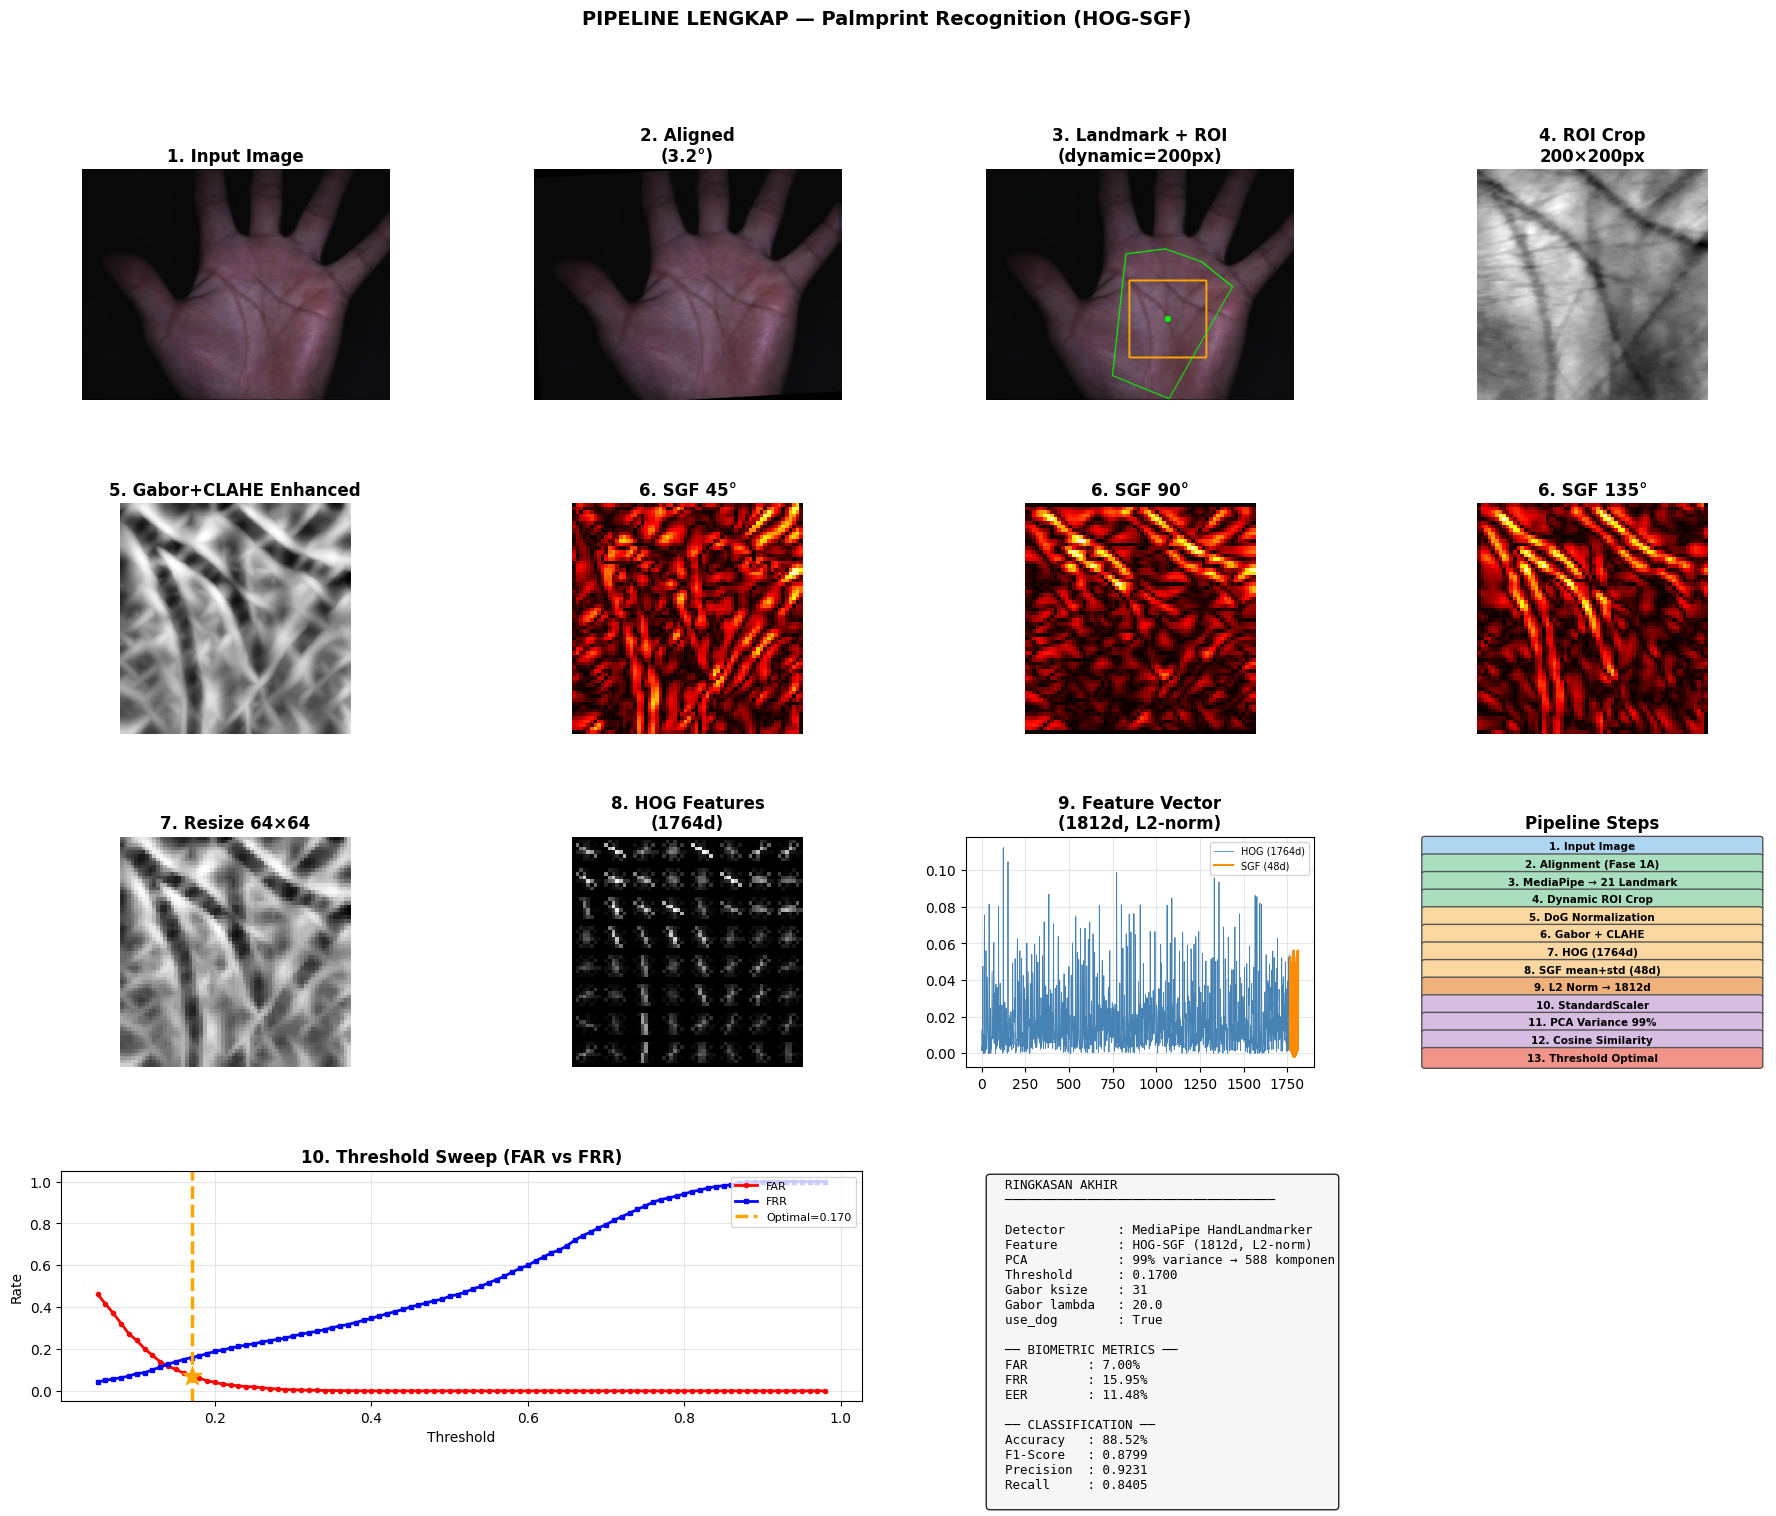

✓ Visualisasi pipeline selesai

✅ SELESAI!
   Model  : d:\xampp\htdocs\palmprint-backend\palmprint-ml\models/
   Output : d:\xampp\htdocs\palmprint-backend\palmprint-ml\results/

File model yang tersimpan:
  best_config.json          (0.6 KB)
  pca.pkl                   (8352.8 KB)
  scaler.pkl                (43.1 KB)
  threshold.pkl             (0.1 KB)


In [102]:
### BAGIAN 10 — VISUALISASI PIPELINE LENGKAP

print('\n[10] Visualisasi pipeline lengkap...')

if samples:
    img_pl     = cv2.imread(os.path.join(Config.DATASET_PATH, samples[0]))
    roi_pl, dbg_pl = detect_palm_opencv(img_pl)
    enh_pl     = enhance_gabor(roi_pl, use_dog=True)  # ✅ konsisten
    feat_pl, hog_img_pl, img64_pl, Ix_pl, Iy_pl = extract_hog_sgf(enh_pl, visualize=True)

    hog_dim_pl = len(feat_pl) - len(Config.SGF_ANGLES) * 2
    sgf_dim_pl = len(Config.SGF_ANGLES) * 2

    fig = plt.figure(figsize=(22, 16))
    gs  = GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.30)
    fig.suptitle('PIPELINE LENGKAP — Palmprint Recognition (HOG-SGF)',
                 fontsize=14, fontweight='bold')

    # ── Baris 0: Deteksi telapak ──
    img_ann = img_pl.copy()
    rx, ry, rx2, ry2 = dbg_pl['roi_rect']
    cx_, cy_ = dbg_pl['cx'], dbg_pl['cy']
    cv2.rectangle(img_ann, (rx, ry), (rx2, ry2), (0, 165, 255), 3)
    cv2.circle(img_ann, (cx_, cy_), 8, (0, 255, 0), -1)
    if dbg_pl['contour'] is not None:
        cv2.drawContours(img_ann, [dbg_pl['contour']], -1, (0, 255, 0), 2)

    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(cv2.cvtColor(img_pl, cv2.COLOR_BGR2RGB))
    ax.set_title('1. Input Image', fontweight='bold'); ax.axis('off')

    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(cv2.cvtColor(dbg_pl['img_aligned'], cv2.COLOR_BGR2RGB))
    ax.set_title(f'2. Aligned\n({dbg_pl["angle"]:.1f}°)', fontweight='bold'); ax.axis('off')

    ax = fig.add_subplot(gs[0, 2])
    ax.imshow(cv2.cvtColor(img_ann, cv2.COLOR_BGR2RGB))
    ax.set_title(f'3. Landmark + ROI\n(dynamic={dbg_pl["dynamic_roi_size"]}px)', fontweight='bold')
    ax.axis('off')

    ax = fig.add_subplot(gs[0, 3])
    ax.imshow(roi_pl, cmap='gray')
    ax.set_title(f'4. ROI Crop\n{Config.ROI_SIZE}×{Config.ROI_SIZE}px', fontweight='bold')
    ax.axis('off')

    # ── Baris 1: Enhancement & SGF ──
    ax = fig.add_subplot(gs[1, 0])
    ax.imshow(enh_pl, cmap='gray')
    ax.set_title('5. Gabor+CLAHE Enhanced', fontweight='bold'); ax.axis('off')

    for col, (theta, lbl) in enumerate(
        zip([np.pi/4, np.pi/2, 3*np.pi/4], ['SGF 45°', 'SGF 90°', 'SGF 135°'])
    ):
        FR   = np.cos(theta) * Ix_pl + np.sin(theta) * Iy_pl
        FR_n = cv2.normalize(np.abs(FR), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        ax   = fig.add_subplot(gs[1, col + 1])
        ax.imshow(FR_n, cmap='hot')
        ax.set_title(f'6. {lbl}', fontweight='bold'); ax.axis('off')

    # ── Baris 2: HOG & feature vector ──
    ax = fig.add_subplot(gs[2, 0])
    ax.imshow(img64_pl, cmap='gray')
    ax.set_title(f'7. Resize {Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}', fontweight='bold')
    ax.axis('off')

    ax = fig.add_subplot(gs[2, 1])
    ax.imshow(hog_img_pl, cmap='gray')
    ax.set_title(f'8. HOG Features\n({hog_dim_pl}d)', fontweight='bold'); ax.axis('off')

    ax = fig.add_subplot(gs[2, 2])
    ax.plot(feat_pl[:hog_dim_pl], lw=0.6, color='steelblue', label=f'HOG ({hog_dim_pl}d)')
    ax.plot(range(hog_dim_pl, hog_dim_pl + sgf_dim_pl),
            feat_pl[hog_dim_pl:], lw=1.5, color='darkorange', label=f'SGF ({sgf_dim_pl}d)')
    ax.set_title(f'9. Feature Vector\n({len(feat_pl)}d, L2-norm)', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Pipeline steps box
    ax = fig.add_subplot(gs[2, 3]); ax.axis('off')
    steps = [
        ('1. Input Image',               '#AED6F1'),
        ('2. Alignment (Fase 1A)',        '#A9DFBF'),
        ('3. MediaPipe → 21 Landmark',   '#A9DFBF'),
        ('4. Dynamic ROI Crop',          '#A9DFBF'),
        ('5. DoG Normalization',         '#FAD7A0'),
        ('6. Gabor + CLAHE',             '#FAD7A0'),
        ('7. HOG (1764d)',               '#FAD7A0'),
        ('8. SGF mean+std (48d)',         '#FAD7A0'),
        ('9. L2 Norm → 1812d',           '#F0B27A'),
        ('10. StandardScaler',           '#D7BDE2'),
        ('11. PCA Variance 99%',         '#D7BDE2'),
        ('12. Cosine Similarity',        '#D7BDE2'),
        ('13. Threshold Optimal',        '#F1948A'),
    ]
    box_h = 0.070
    gap   = (1.0 - len(steps) * box_h) / (len(steps) + 1)
    for i, (txt, color) in enumerate(steps):
        y_ = 1.0 - gap * (i + 1) - box_h * (i + 1)
        rect = patches.FancyBboxPatch(
            (0.02, y_), 0.96, box_h,
            boxstyle='round,pad=0.01',
            facecolor=color, edgecolor='#555', lw=1,
            transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)
        ax.text(0.5, y_ + box_h / 2, txt, transform=ax.transAxes,
                fontsize=7.5, ha='center', va='center', fontweight='bold')
    ax.set_title('Pipeline Steps', fontweight='bold')

    # ── Baris 3: FAR/FRR sweep & ringkasan ──
    # ✅ Pakai variabel dari Cell 7 (ths, fars, frrs, accs, f1s)
    ax = fig.add_subplot(gs[3, 0:2])
    ax.plot(ths, fars, 'r-o', ms=3, lw=2, label='FAR')
    ax.plot(ths, frrs, 'b-s', ms=3, lw=2, label='FRR')
    ax.axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2.5,
               label=f'Optimal={THRESHOLD_OPTIMAL:.3f}')
    ax.scatter([THRESHOLD_OPTIMAL], [best_f1['far']],
               color='orange', s=200, zorder=5, marker='*')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Rate')
    ax.set_title('10. Threshold Sweep (FAR vs FRR)', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3)

    # ✅ Ringkasan pakai variabel dari Cell 8 yang benar
    ax = fig.add_subplot(gs[3, 2:4]); ax.axis('off')
    ax.text(0.03, 0.97,
        f'  RINGKASAN AKHIR\n  {"─"*36}\n\n'
        f'  Detector       : MediaPipe HandLandmarker\n'
        f'  Feature        : HOG-SGF ({len(feat_pl)}d, L2-norm)\n'
        f'  PCA            : {Config.PCA_VARIANCE*100:.0f}% variance → {pca.n_components_} komponen\n'
        f'  Threshold      : {THRESHOLD_OPTIMAL:.4f}\n'
        f'  Gabor ksize    : {Config.GABOR_KSIZE}\n'
        f'  Gabor lambda   : {Config.GABOR_LAMBDA}\n'
        f'  use_dog        : True\n\n'
        f'  ── BIOMETRIC METRICS ──\n'
        f'  FAR        : {far*100:.2f}%\n'
        f'  FRR        : {frr*100:.2f}%\n'
        f'  EER        : {eer*100:.2f}%\n\n'
        f'  ── CLASSIFICATION ──\n'
        f'  Accuracy   : {accuracy*100:.2f}%\n'
        f'  F1-Score   : {f1:.4f}\n'
        f'  Precision  : {precision:.4f}\n'
        f'  Recall     : {recall:.4f}\n',
        transform=ax.transAxes, fontsize=9, va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.85)
    )

    plt.tight_layout()
    plt.show()
    print('✓ Visualisasi pipeline selesai')

print('\n✅ SELESAI!')
print(f'   Model  : {os.path.abspath(Config.MODELS_DIR)}/')
print(f'   Output : {os.path.abspath(Config.OUTPUT_PATH)}/')
print()
print('File model yang tersimpan:')
for f in sorted(os.listdir(Config.MODELS_DIR)):
    path = os.path.join(Config.MODELS_DIR, f)
    print(f'  {f:<25} ({os.path.getsize(path)/1024:.1f} KB)')

### HYPERPARAMETER TUNING

In [103]:
# PARAM_GRID = {
#     # Orientasi HOG — 8 kadang lebih baik untuk garis diagonal palmprint
#     'hog_orient'  : [6, 8, 9],
#     # Ukuran cell — 4px terlalu kecil untuk image 64px
#     'hog_pixels'  : [8, 12, 16],
#     # Ukuran block — 4 cells tangkap konteks lebih luas
#     'hog_cells'   : [2, 3, 4],
#     # PCA variance — 0.90 terlalu agresif untuk >100 subject
#     'pca_variance': [0.95, 0.97, 0.99],
# }
#
# def _run_one_config(orient, pixels, cells, pca_var):
#     """Latih dan evaluasi satu kombinasi parameter. Return dict hasil."""
#     exts  = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
#     files = [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]
#     feats, labs = [], []
#     for fname in files:
#         img = cv2.imread(os.path.join(Config.DATASET_PATH, fname))
#         if img is None: continue
#         roi, _   = detect_palm_opencv(img)
#         enhanced = enhance_gabor(roi)
#         feat     = extract_hog_sgf(enhanced, hog_orient=orient,
#                                    hog_pixels=pixels, hog_cells=cells)
#         feats.append(feat); labs.append(parse_label(fname))
#     X_, y_ = np.array(feats), np.array(labs)
#     X_tr_, X_ts_, y_tr_, y_ts_ = train_test_split(
#         X_, y_, test_size=0.3, stratify=y_, random_state=42
#     )
#     scl     = StandardScaler()
#     X_tr_sc = scl.fit_transform(X_tr_)
#     X_ts_sc = scl.transform(X_ts_)
#     pca_    = PCA(n_components=pca_var, whiten=True, random_state=42)
#     X_tr_p  = pca_.fit_transform(X_tr_sc)
#     X_ts_p  = pca_.transform(X_ts_sc)
#     best_f1, best_th = 0, 0.5
#     for th in np.arange(0.30, 0.96, 0.05):
#         preds, _ = cosine_predict(X_tr_p, y_tr_, X_ts_p, th)
#         ps       = np.where(preds != 'UNKNOWN', preds, '__WRONG__')
#         f1_      = f1_score(y_ts_, ps, average='weighted', zero_division=0)
#         if f1_ > best_f1:
#             best_f1, best_th = f1_, th
#     return {
#         'orient': orient, 'pixels': pixels, 'cells': cells,
#         'pca_var': pca_var, 'best_threshold': best_th,
#         'best_f1': best_f1, 'n_comp': pca_.n_components_
#     }
#
# from itertools import product as iterproduct
# combos = list(iterproduct(PARAM_GRID['hog_orient'], PARAM_GRID['hog_pixels'],
#                           PARAM_GRID['hog_cells'],  PARAM_GRID['pca_variance']))
# print(f'Total kombinasi: {len(combos)}')
#
# tuning_results = []
# for i, (orient, pixels, cells, pca_var) in enumerate(tqdm(combos, desc='Tuning')):
#     r = _run_one_config(orient, pixels, cells, pca_var)
#     tuning_results.append(r)
#     if (i + 1) % 5 == 0:
#         best_so_far = max(x['best_f1'] for x in tuning_results)
#         print(f'  [{i+1}/{len(combos)}] best F1 so far: {best_so_far:.4f}')
#
# best_tune   = max(tuning_results, key=lambda r: r['best_f1'])
# BEST_PARAMS = {
#     'hog_orient'  : best_tune['orient'],
#     'hog_pixels'  : best_tune['pixels'],
#     'hog_cells'   : best_tune['cells'],
#     'pca_variance': best_tune['pca_var'],
#     'threshold'   : best_tune['best_threshold'],
# }
# print('\n✓ BEST PARAMS dari tuning:')
# for k, v in BEST_PARAMS.items():
#     print(f'  {k:<15}: {v}')
# print(f'  F1-Score terbaik: {best_tune["best_f1"]:.4f}')
#
# # Visualisasi hasil tuning
# f1_vals    = [r['best_f1'] for r in tuning_results]
# labels_tun = [f"or={r['orient']},px={r['pixels']},bl={r['cells']},pca={r['pca_var']}"
#               for r in tuning_results]
# top20_idx  = np.argsort(f1_vals)[::-1][:20]
#
# fig, ax = plt.subplots(figsize=(14, 5))
# ax.barh(range(20), [f1_vals[i] for i in top20_idx],
#         color='steelblue', alpha=0.8, edgecolor='navy')
# ax.set_yticks(range(20))
# ax.set_yticklabels([labels_tun[i] for i in top20_idx], fontsize=8)
# ax.set_xlabel('F1-Score (strict)')
# ax.set_title('Top 20 Kombinasi Hyperparameter', fontweight='bold')
# ax.grid(True, alpha=0.3, axis='x')
# plt.tight_layout()
# plt.show()